## AI PROJECT

### Intelligent Used Car Valuation Engine: A Machine Learning Approach for the Pakistani Automotive Market

##### DATA CLEANING and PREPROCESSING:

A three level dictionary is used for the make model variant where each of them are stored in a dictionary for hierarchy like if a make is defined then only that make's models will come in the drop down menu of UI and if a model is selected then only that model's specific variants will be listed in the drop down menu

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib
import re

print("Loading data...")
df = pd.read_csv("PakWheelsDataSet.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore').dropna()
df['Car_Age'] = 2026 - df['Year'] 
df = df.drop(columns=['Year'])

# AGGRESSIVE VARIANT CLEANING
# 1. Remove ratings (e.g., 8.5/10)
df['Name'] = df['Name'].apply(lambda x: re.sub(r'\s*\d+(\.\d+)?/10', '', str(x)))
# 2. Remove common garbage phrases (case insensitive) like "For Sale", "In Lahore", etc.
df['Name'] = df['Name'].str.replace(r'(?i)(for sale|in pakistan|used|new)', '', regex=True)
# 3. Clean up extra accidental spaces
df['Name'] = df['Name'].apply(lambda x: " ".join(str(x).split()))

# Extract Model and Variant
df['Model'] = df['Name'].apply(lambda x: str(x).split()[0])
df['Variant'] = df['Name'].apply(lambda x: " ".join(str(x).split()[1:]) if len(str(x).split()) > 1 else 'Standard')
df = df.drop(columns=['Name']) 

# Geographic Binning
top_cities = ['Lahore', 'Karachi', 'Islamabad', 'Rawalpindi', 'Peshawar', 'Multan', 'Faisalabad']
df['City'] = df['City'].apply(lambda x: x if x in top_cities else 'Other')

# Outliers
df = df[(df['Price'] >= 200000) & (df['Price'] <= 100000000)]
df = df[df['Mileage(kms)'] <= 500000]
df = df[(df['Engine Capacity(CC)'] >= 660) & (df['Engine Capacity(CC)'] <= 7000)]

# UI DICTIONARY
# We now map exactly what Transmission, Fuel, and Engine CC belong to each Variant!
ui_dict = {}
for make, make_data in df.groupby('Make'):
    ui_dict[make] = {}
    for model, model_data in make_data.groupby('Model'):
        ui_dict[make][model] = {}
        for variant, variant_data in model_data.groupby('Variant'):
            ui_dict[make][model][variant] = {
                'Transmission': variant_data['Transmission'].dropna().unique().tolist(),
                'Engine Type': variant_data['Engine Type'].dropna().unique().tolist(),
                # We sort the CCs so they look nice in the dropdown
                'Engine CC': sorted(variant_data['Engine Capacity(CC)'].dropna().unique().tolist())
            }

joblib.dump(ui_dict, 'make_model_variant_dict.pkl')
print("Bulletproof Dictionary Exported!")

# Categorical Encoding
categorical_cols = ['Make', 'Model', 'Variant', 'Transmission', 'Engine Type', 'City']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int) 

# Min-Max Scaling
scaler = MinMaxScaler()
numerical_features = ['Mileage(kms)', 'Engine Capacity(CC)', 'Car_Age']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

df.to_csv("Phase1_Preprocessed_PakWheels.csv", index=False)
print("Phase 1 Complete!")

Loading data...
Bulletproof Dictionary Exported!
Phase 1 Complete!


#### DATA VISUZALIZATION

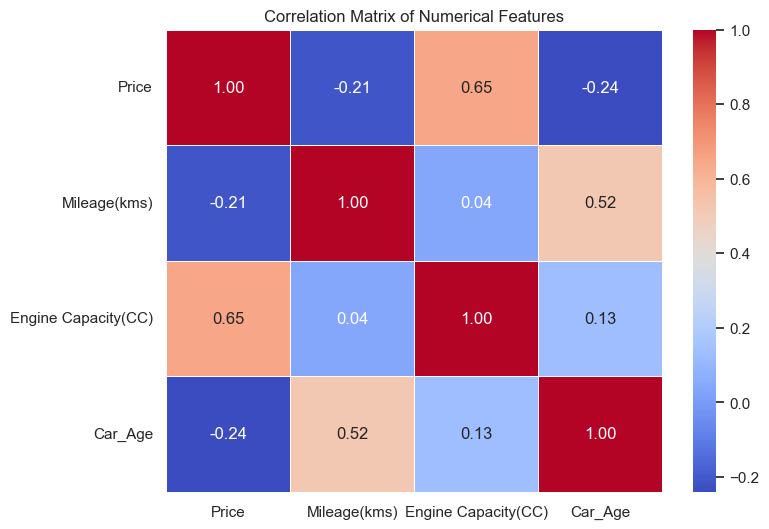

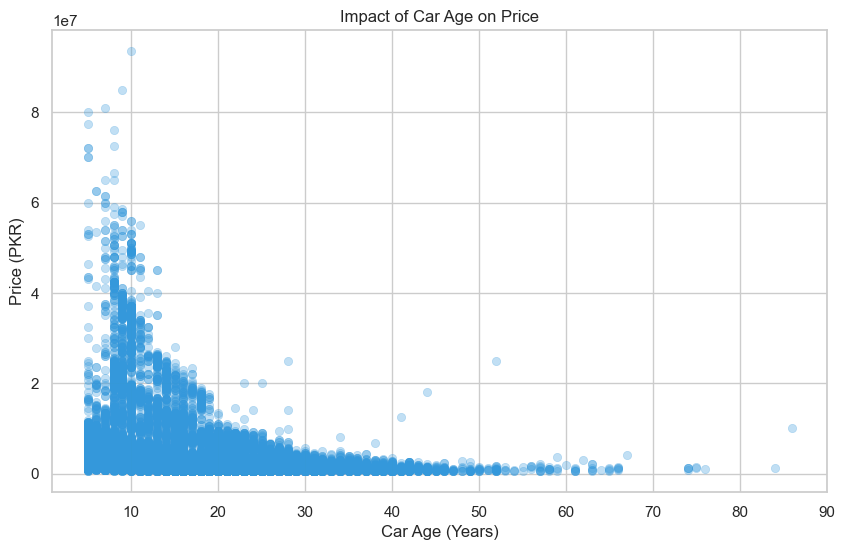

C:\Users\hp\AppData\Local\Temp\ipykernel_8680\54884023.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='magma')


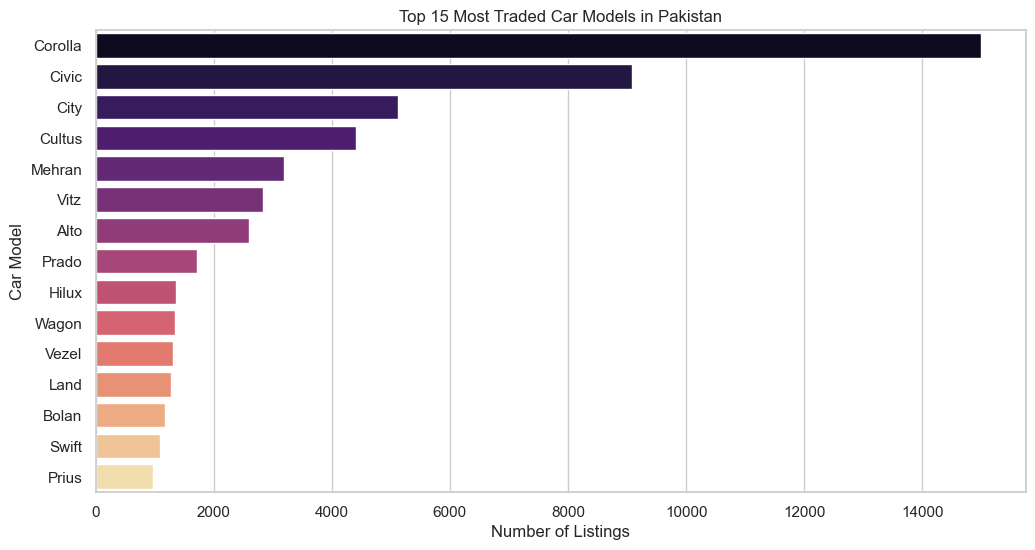

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load a fresh copy of the raw data specifically for Visualization
viz_df = pd.read_csv("PakWheelsDataSet.csv")
viz_df = viz_df.drop(columns=['Unnamed: 0'], errors='ignore').dropna()

# 2. Calculate the features needed for the graphs
viz_df['Car_Age'] = 2026 - viz_df['Year']
viz_df['Model'] = viz_df['Name'].apply(lambda x: str(x).split()[0])

# 3. Apply our Domain Thresholds to keep the graphs clean (removing outliers)
viz_df = viz_df[(viz_df['Price'] >= 200000) & (viz_df['Price'] <= 100000000)]
viz_df = viz_df[viz_df['Mileage(kms)'] <= 500000]
viz_df = viz_df[(viz_df['Engine Capacity(CC)'] >= 660) & (viz_df['Engine Capacity(CC)'] <= 7000)]

# Set the visual style
sns.set_theme(style="whitegrid")

# Plot 1: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = viz_df[['Price', 'Mileage(kms)', 'Engine Capacity(CC)', 'Car_Age']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Plot 2: Car Age vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Car_Age', y='Price', data=viz_df, alpha=0.3, color='#3498db', edgecolor=None)
plt.title('Impact of Car Age on Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Price (PKR)')
plt.show()

# Plot 3: Top 15 Most Traded Car Models
plt.figure(figsize=(12, 6))
top_models = viz_df['Model'].value_counts().nlargest(15)
sns.barplot(x=top_models.values, y=top_models.index, palette='magma')
plt.title('Top 15 Most Traded Car Models in Pakistan')
plt.xlabel('Number of Listings')
plt.ylabel('Car Model')
plt.show()

In [33]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Loading preprocessed data

In [34]:
print("Loading Preprocessed Data...")
df_processed = pd.read_csv("Phase1_Preprocessed_PakWheels.csv")

Loading Preprocessed Data...


Define Features (X) and Target (y)

Train-Test Split (80% Training, 20% Testing)

In [35]:
X = df_processed.drop(columns=['Price'], errors='ignore')
y = df_processed['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Evaluation Function

In [36]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Performance")
    print(f"Mean Absolute Error (MAE): {mae:,.2f} PKR")
    print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} PKR")
    print(f"R-Squared (R2 Score): {r2:.4f}({r2 * 100:.2f}%)")

#### MACHINE LEARNING MODELS IMPLEMENTATION

Multiple Linear Regression

In [37]:
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

Training Linear Regression...


Installing Library for Gradient Boosting

In [ ]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.0 MB/s eta 0:00:35
   - -------------------------------------- 2.9/101.7 MB 5.6 MB/s eta 0:00:18
   -- ------------------------------------- 5.2/101.7 MB 7.5 MB/s eta 0:00:13
   -- ------------------------------------- 5.2/101.7 MB 7.5 MB/s eta 0:00:13
   --- ------------------------------------ 8.1/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 9.2/101.7 MB 7.0 MB/s eta 0:00:14
   --- ------------------------------------ 9.7/101.7 MB 6.6 MB/s eta 0:00:15
   --- ------------------------------------ 9.7/101.7 MB 6.6 MB/s eta 0:00:15
   ----- ---------------------------------- 12.8/101.7 MB 7.1 MB/s eta 0:00:13
   ----- ----


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### GRADIENT BOOSTING

In [38]:
print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,      # Number of sequential trees
    learning_rate=0.1,     # How much each tree learns from the mistakes of the last
    max_depth=8,           # Depth of the trees (captures complex car pricing logic)
    random_state=42,
    n_jobs=-1              
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

Training XGBoost Regressor...


#### Random Forest Regressor
Done this for comparison with GB

In [39]:
print("\nTraining Random Forest....")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


Training Random Forest....


In [40]:
evaluate(y_test, y_pred_lr, "Multiple Linear Regression")
evaluate(y_test, y_pred_xgb, "XGBoost Regressor")
evaluate(y_test, y_pred_rf, "Random Forest Regressor")


Multiple Linear Regression Performance
Mean Absolute Error (MAE): 427,669.41 PKR
Root Mean Squared Error (RMSE): 1,165,521.34 PKR
R-Squared (R2 Score): 0.9273(92.73%)

XGBoost Regressor Performance
Mean Absolute Error (MAE): 245,734.13 PKR
Root Mean Squared Error (RMSE): 721,098.47 PKR
R-Squared (R2 Score): 0.9722(97.22%)

Random Forest Regressor Performance
Mean Absolute Error (MAE): 199,902.19 PKR
Root Mean Squared Error (RMSE): 721,593.49 PKR
R-Squared (R2 Score): 0.9721(97.21%)


While XGBoost is usually the champion of Kaggle competitions, random forst got an advantage on this sort of data that i created. Both of these are Ensemble models, meaning they dont just build one decision tree, they build hundreds of them and combine answers, the difference comes in the method they combine them with. 

Random Forest: It build 100 different decision tree and performs evaluation on all those 100 trees separately for the same set of data and then averages those 100 values to basically minimize the extremes

Gradient Boosting: It builds trees sequentially one by one. Tree 1 takes a set, performs evaluation and predicts, tree 2 doesnt look at the whole dataset but the wrong evaluations only and excludes the errors from that. now the tree 3 fixes tree 2's errors

In [17]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import joblib

# We were using XGBoost model for the Streamlit App but after we saw the performance metrics, we noticed that Random Forest performed better! So we will export the Random Forest model for the App instead of XGBoost.
# now changing xgb_model to rf_model below!
joblib.dump(rf_model, 'random_forest_car_price_model.pkl')

# Export the Min-Max Scaler (this ensures the app scales user input correctly)
joblib.dump(scaler, 'minmax_scaler.pkl')

joblib.dump(list(X.columns), 'expected_columns.pkl')

print("\nPhase 2 Complete! AI models trained and exported for the App.")


Phase 2 Complete! AI models trained and exported for the App.
